In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')

project_path = '/content/drive/MyDrive'
os.chdir(project_path)

Mounted at /content/drive


=== Vocabulary Size Ablation ===
Vocab 1000, LR: Accuracy=0.8503, Time=0.30s
Vocab 1000, NB: Accuracy=0.8296, Time=0.09s
Vocab 2500, LR: Accuracy=0.8711, Time=0.34s
Vocab 2500, NB: Accuracy=0.8436, Time=0.14s
Vocab 5000, LR: Accuracy=0.8802, Time=0.22s
Vocab 5000, NB: Accuracy=0.8542, Time=0.09s
Vocab 7500, LR: Accuracy=0.8804, Time=0.23s
Vocab 7500, NB: Accuracy=0.8611, Time=0.11s
Vocab 10000, LR: Accuracy=0.8825, Time=0.27s
Vocab 10000, NB: Accuracy=0.8605, Time=0.11s
Vocab 15000, LR: Accuracy=0.8832, Time=0.47s
Vocab 15000, NB: Accuracy=0.8617, Time=0.11s
Vocab 20000, LR: Accuracy=0.8837, Time=0.81s
Vocab 20000, NB: Accuracy=0.8639, Time=0.16s

=== N-gram Range Ablation ===
N-grams (1, 1), LR: Accuracy=0.8786
N-grams (1, 1), NB: Accuracy=0.8449
N-grams (1, 2), LR: Accuracy=0.8825
N-grams (1, 2), NB: Accuracy=0.8605
N-grams (1, 3), LR: Accuracy=0.8825
N-grams (1, 3), NB: Accuracy=0.8592
N-grams (2, 2), LR: Accuracy=0.7911
N-grams (2, 2), NB: Accuracy=0.7973
N-grams (2, 3), LR: Accura

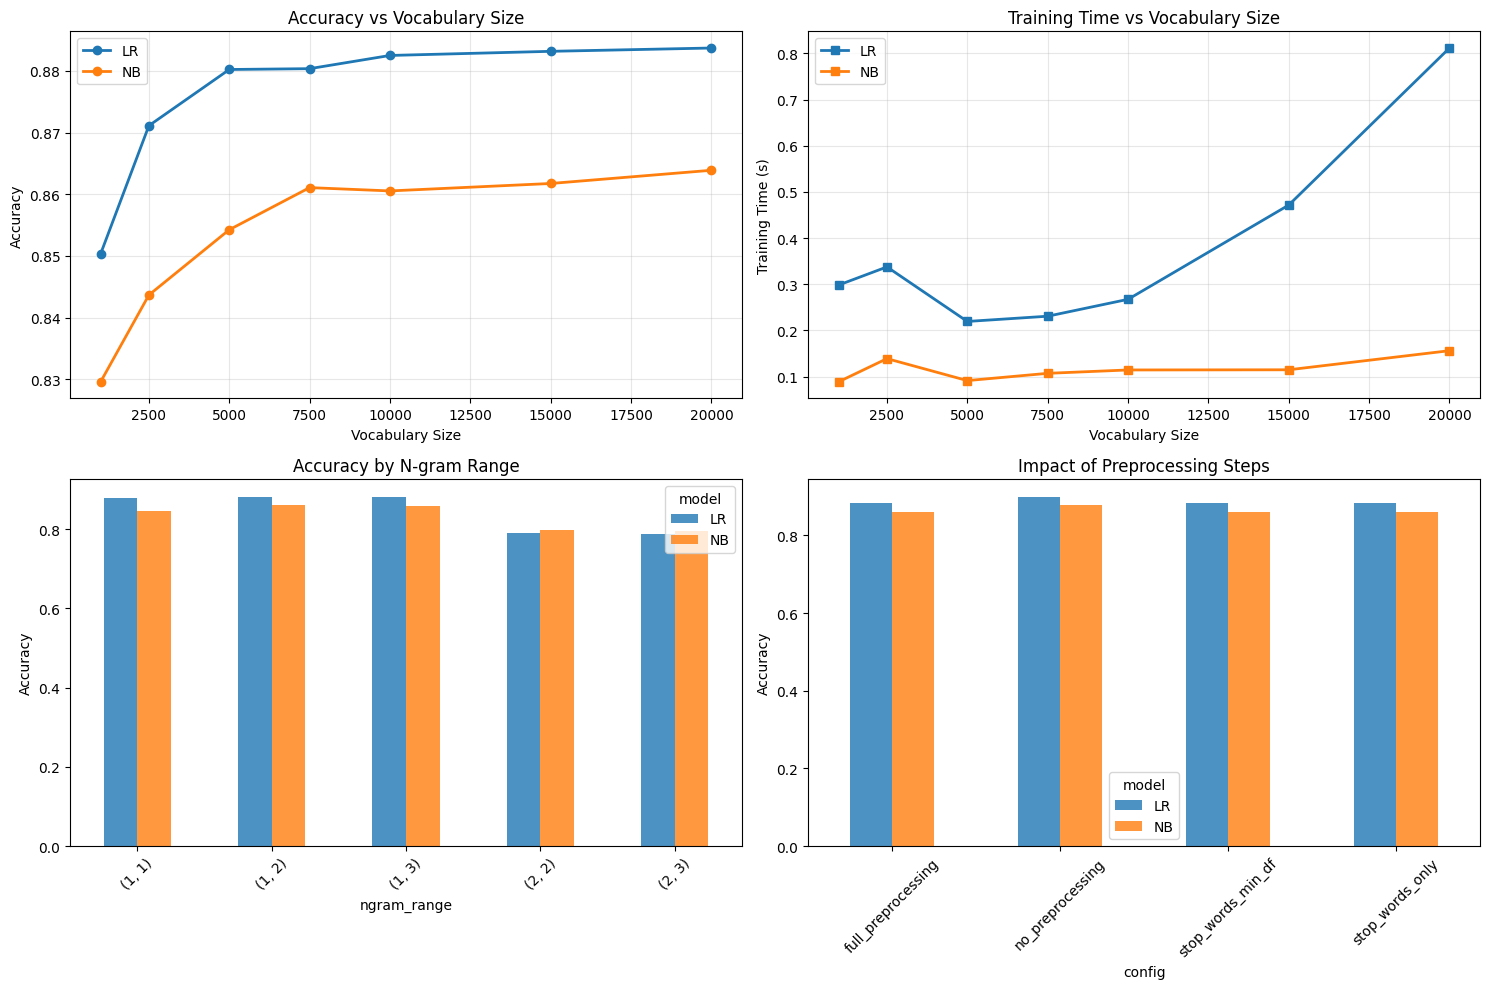

In [2]:

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score
import time
import matplotlib.pyplot as plt
import seaborn as sns

class AblationStudy:
    def __init__(self, X_train, y_train, X_val, y_val):
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.results = []

    def run_vocabulary_study(self):
        """Study impact of vocabulary size"""
        print("=== Vocabulary Size Ablation ===")
        vocab_sizes = [1000, 2500, 5000, 7500, 10000, 15000, 20000]

        for vocab_size in vocab_sizes:
            # TF-IDF with different vocabulary sizes
            tfidf = TfidfVectorizer(
                max_features=vocab_size,
                min_df=5,
                max_df=0.7,
                ngram_range=(1,2),
                stop_words='english'
            )

            X_train_tfidf = tfidf.fit_transform(self.X_train)
            X_val_tfidf = tfidf.transform(self.X_val)

            # Test both models
            for model_name, model in [('LR', LogisticRegression()), ('NB', MultinomialNB())]:
                start_time = time.time()
                model.fit(X_train_tfidf, self.y_train)
                y_pred = model.predict(X_val_tfidf)
                training_time = time.time() - start_time

                accuracy = accuracy_score(self.y_val, y_pred)
                f1 = f1_score(self.y_val, y_pred, average='weighted')

                self.results.append({
                    'experiment': 'vocabulary_size',
                    'model': model_name,
                    'vocab_size': vocab_size,
                    'accuracy': accuracy,
                    'f1_score': f1,
                    'training_time': training_time,
                    'feature_dim': X_train_tfidf.shape[1]
                })
                print(f"Vocab {vocab_size}, {model_name}: Accuracy={accuracy:.4f}, Time={training_time:.2f}s")

    def run_ngram_study(self):
        """Study impact of n-gram ranges"""
        print("\n=== N-gram Range Ablation ===")
        ngram_ranges = [(1,1), (1,2), (1,3), (2,2), (2,3)]

        for ngram_range in ngram_ranges:
            tfidf = TfidfVectorizer(
                max_features=10000,
                min_df=5,
                max_df=0.7,
                ngram_range=ngram_range,
                stop_words='english'
            )

            X_train_tfidf = tfidf.fit_transform(self.X_train)
            X_val_tfidf = tfidf.transform(self.X_val)

            for model_name, model in [('LR', LogisticRegression()), ('NB', MultinomialNB())]:
                model.fit(X_train_tfidf, self.y_train)
                y_pred = model.predict(X_val_tfidf)

                accuracy = accuracy_score(self.y_val, y_pred)
                f1 = f1_score(self.y_val, y_pred, average='weighted')

                self.results.append({
                    'experiment': 'ngram_range',
                    'model': model_name,
                    'ngram_range': str(ngram_range),
                    'accuracy': accuracy,
                    'f1_score': f1,
                    'feature_dim': X_train_tfidf.shape[1]
                })
                print(f"N-grams {ngram_range}, {model_name}: Accuracy={accuracy:.4f}")

    def run_preprocessing_study(self):
        """Study impact of different preprocessing choices"""
        print("\n=== Preprocessing Ablation ===")

        preprocessing_configs = [
            {'stop_words': None, 'min_df': 1, 'max_df': 1.0, 'name': 'no_preprocessing'},
            {'stop_words': 'english', 'min_df': 1, 'max_df': 1.0, 'name': 'stop_words_only'},
            {'stop_words': 'english', 'min_df': 5, 'max_df': 1.0, 'name': 'stop_words_min_df'},
            {'stop_words': 'english', 'min_df': 5, 'max_df': 0.7, 'name': 'full_preprocessing'},
        ]

        for config in preprocessing_configs:
            tfidf = TfidfVectorizer(
                max_features=10000,
                min_df=config['min_df'],
                max_df=config['max_df'],
                ngram_range=(1,2),
                stop_words=config['stop_words']
            )

            X_train_tfidf = tfidf.fit_transform(self.X_train)
            X_val_tfidf = tfidf.transform(self.X_val)

            for model_name, model in [('LR', LogisticRegression()), ('NB', MultinomialNB())]:
                model.fit(X_train_tfidf, self.y_train)
                y_pred = model.predict(X_val_tfidf)

                accuracy = accuracy_score(self.y_val, y_pred)

                self.results.append({
                    'experiment': 'preprocessing',
                    'model': model_name,
                    'config': config['name'],
                    'accuracy': accuracy,
                    'feature_dim': X_train_tfidf.shape[1]
                })
                print(f"Config {config['name']}, {model_name}: Accuracy={accuracy:.4f}")

    def visualize_results(self):
        """Create visualization plots for ablation results"""
        results_df = pd.DataFrame(self.results)

        # Vocabulary size impact
        vocab_results = results_df[results_df['experiment'] == 'vocabulary_size']

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Accuracy vs Vocabulary Size
        for model in ['LR', 'NB']:
            model_data = vocab_results[vocab_results['model'] == model]
            axes[0,0].plot(model_data['vocab_size'], model_data['accuracy'],
                          marker='o', label=model, linewidth=2)
        axes[0,0].set_xlabel('Vocabulary Size')
        axes[0,0].set_ylabel('Accuracy')
        axes[0,0].set_title('Accuracy vs Vocabulary Size')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)

        # Training Time vs Vocabulary Size
        for model in ['LR', 'NB']:
            model_data = vocab_results[vocab_results['model'] == model]
            axes[0,1].plot(model_data['vocab_size'], model_data['training_time'],
                          marker='s', label=model, linewidth=2)
        axes[0,1].set_xlabel('Vocabulary Size')
        axes[0,1].set_ylabel('Training Time (s)')
        axes[0,1].set_title('Training Time vs Vocabulary Size')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)

        # N-gram range comparison
        ngram_results = results_df[results_df['experiment'] == 'ngram_range']
        ngram_pivot = ngram_results.pivot_table(index='ngram_range', columns='model', values='accuracy')
        ngram_pivot.plot(kind='bar', ax=axes[1,0], alpha=0.8)
        axes[1,0].set_title('Accuracy by N-gram Range')
        axes[1,0].set_ylabel('Accuracy')
        axes[1,0].tick_params(axis='x', rotation=45)

        # Preprocessing impact
        prep_results = results_df[results_df['experiment'] == 'preprocessing']
        prep_pivot = prep_results.pivot_table(index='config', columns='model', values='accuracy')
        prep_pivot.plot(kind='bar', ax=axes[1,1], alpha=0.8)
        axes[1,1].set_title('Impact of Preprocessing Steps')
        axes[1,1].set_ylabel('Accuracy')
        axes[1,1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.savefig('ablation_studies.png', dpi=300, bbox_inches='tight')
        plt.show()

        return results_df

# Usage code
def run_ablation_studies():
    train_df = pd.read_csv('train.csv')
    val_df = pd.read_csv('validation.csv')

    X_train = train_df['review']
    y_train = train_df['label']
    X_val = val_df['review']
    y_val = val_df['label']

    ablation = AblationStudy(X_train, y_train, X_val, y_val)
    ablation.run_vocabulary_study()
    ablation.run_ngram_study()
    ablation.run_preprocessing_study()

    results_df = ablation.visualize_results()
    results_df.to_csv('ablation_results.csv', index=False)

    return results_df

# Run the studies
ablation_results = run_ablation_studies()